## Lagrange and Newton Interpolation

**Name: Jiaen Qi**

**Date: 08/15/2026**

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

- Then define our function to be:

In [ ]:
def f(x):
  return np.cos(x) + np.sin(x)

## Lagrange Interpolation

## Explanation:

The Lagrange interpolation polynomial of degree 4 is

$$
P_4(x)=\sum_{i=0}^{4} f(x_i)L_i(x),
$$

where the Lagrange basis polynomials are

$$
L_i(x)=\prod_{\substack{j=0 \\ j\ne i}}^{4}
\frac{x-x_j}{x_i-x_j}.
$$

Each basis polynomial $L_i(x)$ is constructed to satisfy

$$
L_i(x_j)=
\begin{cases}
1, & i=j,\\
0, & i\ne j.
\end{cases}
$$

This means that $L_i(x)$ selects the function value at $x_i$. At $x=x_i$, the corresponding basis polynomial equals $1$, while all the other basis polynomials equal $0$.

Therefore,

$$
P_4(x_i)
=
\sum_{j=0}^{4} f(x_j)L_j(x_i)
=
f(x_i),
$$

so the Lagrange interpolation polynomial passes exactly through all five interpolation points.

## Implementation:

Now we will define a Python function that evaluates the Lagrange polynomial for a set of distinct nodes.

**Note**: The Lagrange interpolation polynomial is evaluated by first computing each
basis polynomial $$L_i(x)$$, multiplying it by $$f(x_i)$$, and then adding
all five terms

In [ ]:
## Given points
x_nodes = np.array([0, 0.25, 0.50, 0.75, 1.00])

## Match points to function
y_nodes = f(x_nodes)

## The Lagrange basis polynomial L_i(x)
def  lagrange_basis(x, i, nodes):
    Li = 1 ## starting value

    ## Multiply all factors except j=i
    for j in range(len(nodes)):
        if j != i:
            Li = Li * (x - nodes[j]) / (nodes[i] - nodes[j])

    return Li

The codes above actually are used to define:
$$
L_i(x)=\prod_{\substack{j=0 \\ j\ne i}}^{4}
\frac{x-x_j}{x_i-x_j}.
$$

In [ ]:
## Then we continue to complete the Lagrange interpolation polynomial
def lagrange_interpolation(x, nodes, values):
    P = 0

    # Add f(x_i)L_i(x) for every interpolation node
    for i in range(len(nodes)):
        P = P + values[i] * lagrange_basis(x, i, nodes)  # values[i] gives f(x_i)

    return P

From the codes above, we have now defined the full Lagrange Interpolation:

$$
P_4(x_i)
=
\sum_{j=0}^{4} f(x_j)L_j(x_i)
$$

In [ ]:
## Then we apply to the given data points and see the results
for x in x_nodes:
    print(
        "x =", x,
        "  f(x) =", f(x),
        "  P4(x) =", lagrange_interpolation(x, x_nodes, y_nodes)
    )

x = 0.0   f(x) = 1.0   P4(x) = 1.0
x = 0.25   f(x) = 1.2163163809651676   P4(x) = 1.2163163809651676
x = 0.5   f(x) = 1.3570081004945758   P4(x) = 1.3570081004945758
x = 0.75   f(x) = 1.413327628897155   P4(x) = 1.413327628897155
x = 1.0   f(x) = 1.3817732906760363   P4(x) = 1.3817732906760363


After expanding and combining the Lagrange terms, we can see that the resulting
degree-4 polynomial is approximately

$$
P_4(x)
=
0.05595578x^4
-0.17724065x^3
-0.49654746x^2
+0.99960562x
+1.
$$

The output confirms that $$P_4(x_i)=f(x_i)$$ at all five interpolation
nodes.

## Experiment and Example

Next, we will evaluate at x=0.85 and x=1.25. Then we will return the true value, approximation and absolute error at each point. And compare a theorectical bound with the actual error.


`Note:` We have the interpolation error formula

$$
f(x)-P_4(x)
=
\frac{f^{(5)}(\xi)}{5!}
\prod_{i=0}^{4}(x-x_i),
$$

Since

$$
f(x)=\cos(x)+\sin(x),
$$

its fifth derivative is

$$
f^{(5)}(x)=\cos(x)-\sin(x).
$$

For the intervals used here,

$$
\max |f^{(5)}(x)|=1.
$$

The maximum value `1` here is what we will replace for $${f^{(5)}(\xi)}$$.

Therefore, the error bound should be

$$
|f(x)-P_4(x)|
\leq
\frac{1}{5!}
\left|
\prod_{i=0}^{4}(x-x_i)
\right|
$$

theoretically.

In [ ]:
# Specify the points where we want to test the interpolation polynomial
test_points = [0.85, 1.25]

# We create an empty list and will add one row of results for each test point
results = []

for x in test_points:
    true_value = f(x)
    approximation = lagrange_interpolation(x, x_nodes, y_nodes)
    absolute_error = abs(true_value - approximation)

 # Calculate the theoretical bound
    error_product = 1

    for node in x_nodes:
        error_product = error_product * (x - node)
    # This loop calculates the product (x-x_0)(x-x_1)(x-x_2)(x-x_3)(x-x_4)

    # 5! = 120 and the maximum fifth derivative is 1
    error_bound = abs(error_product) / 120


# Then we will create a table

    results.append([
        x,
        true_value,
        approximation,
        absolute_error,
        error_bound
    ])

error_table = pd.DataFrame(
    results,
    columns=[
        "x",
        "True Value",
        "P4(x)",
        "Absolute Error",
        "Theoretical Bound"
    ]
)

error_table


,x,True Value,P4(x),Absolute Error,Theoretical Bound
0,0.85,1.411264,1.411271,0.000007,0.000022
1,1.25,1.264307,1.264089,0.000218,0.000977


`Note:` Here we can observe that when x = 0.85, the true value f(x) is `very close` to the approximation P4(x). This is because the selected x value, namely 0.85, is in the interval [0,1].

So conceivably when x is outside of the interval [0,1], namely when x = 1.25, the error between the true value and approximation value will go larger, as we can also observe from the table above.

Next, to verify the intuition that error goes larger if x moves farther from [0,1], we can plot the two functions and see if their graph will look different as x moves away from [0,1].

If yes, then the graph will agree with our compuatutations.

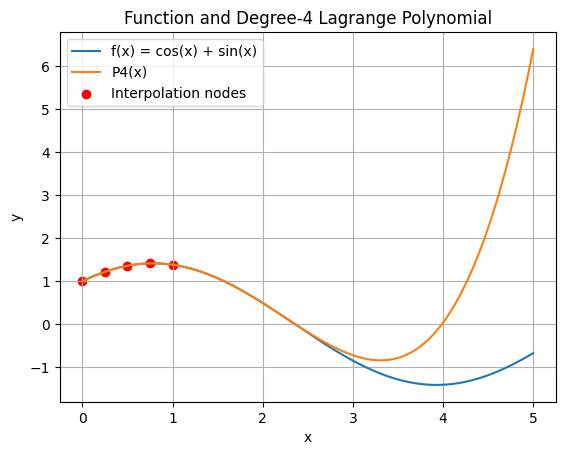

In [ ]:
# Then we will make a graph to plot f and P4 on [0, 5] and mark the five nodes.

x_plot = np.linspace(0, 5, 500)
# This creates 500 evenly spaced x values from 0 to 5.
# More points we use, smoother the plot would look like.



# Then we evaluate f(x) and P_4(x) at all 500 points
f_plot = f(x_plot)
P4_plot = lagrange_interpolation(x_plot, x_nodes, y_nodes)

# Then we plot the original function and the interpolation polynomial

plt.plot(x_plot, f_plot, label="f(x) = cos(x) + sin(x)")
plt.plot(x_plot, P4_plot, label="P4(x)")
plt.scatter(x_nodes, y_nodes, color="red", label="Interpolation nodes")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Function and Degree-4 Lagrange Polynomial")
plt.legend()
plt.grid()
plt.show()
plt.show()


`Note:` We mark the five original interpolation nodes with `red dots` on the graph.

The graph above shows that P4(x) closely follows f(x) near the nodes. But, as x moves farther outside [0,1], the polynomial moves away from the original function because it is used for extrapolation.

The graph supports the numerical results. Our computation and intuition are correct.

## Conclusion

The absolute errors for interpolation are

$$
\begin{aligned}
|f(0.85)-P_4(0.85)| &\approx 7.04\times10^{-6},\\
|f(1.25)-P_4(1.25)| &\approx 2.18\times10^{-4}.
\end{aligned}
$$

Both errors are below their theoretical bounds. The smaller error at
\(x=0.85\) shows that the polynomial is more reliable inside the
interpolation interval than outside it.

## Natural Cubic Spline Interpolation

## Explain

For four data points, the cubic spline consists of three cubic
polynomials:

$$
S(x)=
\begin{cases}
S_0(x), & x\in[x_0,x_1],\\
S_1(x), & x\in[x_1,x_2],\\
S_2(x), & x\in[x_2,x_3].
\end{cases}
$$

On each interval, the cubic polynomial has the form

$$
S_n(x)
=
a_n(x-x_n)^3
+b_n(x-x_n)^2
+c_n(x-x_n)
+d_n,
$$

where

$$
n=0,1,2.
$$

Each polynomial must agree with the following conditions:


**Condition #1:**

$$
S_n(x_n)=f(x_n),
\qquad n=0,1,2.
$$

**Condition #2:**

$$
S_n(x_{n+1})=f(x_{n+1}),
\qquad n=0,1,2.
$$

**Condition #3:**

$$
S_n(x_{n+1})=S_{n+1}(x_{n+1}),
\qquad n=0,1.
$$

**Condition #4:**

$$
S_n'(x_{n+1})=S_{n+1}'(x_{n+1}),
\qquad n=0,1.
$$

**Condition #5:**

$$
S_n''(x_{n+1})=S_{n+1}''(x_{n+1}),
\qquad n=0,1.
$$

**Condition #6: Natural boundary conditions**

$$
S_0''(x_0)=0,
\qquad
S_2''(x_3)=0.
$$

Above is the whole definition of the Cubic Spline Interpolation.

`Note:` A Newton interpolation polynomial uses one degree-3 polynomial over the
entire interval. A cubic spline instead uses three cubic polynomials
that join together with continuous first and second derivatives.

## Implement

For the four nodes

$$
x_0=0,\qquad x_1=1,\qquad x_2=2,\qquad x_3=3,
$$

we use

$$
y_n=f(x_n)=\cos(x_n)+\sin(x_n).
$$

There are three cubic pieces, each having four unknown coefficients:

$$
S_n(x)
=
a_n(x-x_n)^3+b_n(x-x_n)^2+c_n(x-x_n)+d_n.
$$

Therefore, the vector of twelve unknown coefficients is

$$
\mathbf{c}
=
\begin{bmatrix}
a_0&b_0&c_0&d_0&
a_1&b_1&c_1&d_1&
a_2&b_2&c_2&d_2
\end{bmatrix}^{T}.
$$

We construct a system of the form

$$
A\mathbf{c}=\mathbf{b}.
$$

Conditions #1 and #2 provide six equations. Conditions #4 and #5
provide four equations, and Condition #6 provides the final two
equations. Condition #3 is automatically satisfied because the
neighboring pieces equal the same function value at each shared node.

In [ ]:
# Four data points for the natural cubic spline
x_spline = np.array([0, 1, 2, 3])
y_spline = f(x_spline)

# The order of the unknowns is:
# a_0, b_0, c_0, d_0, a_1, b_1, c_1, d_1, a_2, b_2, c_2, d_2

A = np.array([
    # Condition #1: S_n(x_n) = f(x_n)

    # n=0:
    # x_0 = 0, then S_0(0) = a_0*(0^3) + b_0*(0^2) + c_0*(0) + d_0 = f(0)
    # for n = 1, likewise
    [0, 0, 0, 1,  0, 0, 0, 0,  0, 0, 0, 0],
    [0, 0, 0, 0,  0, 0, 0, 1,  0, 0, 0, 0],
    [0, 0, 0, 0,  0, 0, 0, 0,  0, 0, 0, 1],

    # Condition #2: S_n(x_(n+1)) = f(x_(n+1))
    [1, 1, 1, 1,  0, 0, 0, 0,  0, 0, 0, 0], # a_0 + b_0 + c_0 + d_0 = f(x_1)
    [0, 0, 0, 0,  1, 1, 1, 1,  0, 0, 0, 0],
    [0, 0, 0, 0,  0, 0, 0, 0,  1, 1, 1, 1],

    # Condition #4: first derivatives agree
    # for n=0:
    # S_n'(x)=3a_n(x-x_n)^2+2b_n(x-x_n)+c_n
    # At x_1, S_0'(x_1)=3a_0+2b_0+c_0
    # And S_1'(x_1)=c_1
    # So 3a_0+2b_0+c_0=c_1, or 3a_0+2b_0+c_0-c_1=0
    # for n=1, likewise
    [3, 2, 1, 0,  0, 0, -1, 0,  0, 0, 0, 0],
    [0, 0, 0, 0,  3, 2, 1, 0,  0, 0, -1, 0],

    # Condition #5: second derivatives agree
    # for n=0:
    # S_n''(x)=6a_n(x-x_n)+2b_n
    # At x_1, S_0''(x_1)=6a_0+2b_0
    # And S_1''(x_1)=2b_1
    # So, 6a_0+2b_0-2b_1=0
    # for n=1, likewise
    [6, 2, 0, 0,  0, -2, 0, 0,  0, 0, 0, 0],
    [0, 0, 0, 0,  6, 2, 0, 0,  0, -2, 0, 0],

    # Condition #6: natural boundary conditions
    [0, 2, 0, 0,  0, 0, 0, 0,  0, 0, 0, 0],
    [0, 0, 0, 0,  0, 0, 0, 0,  6, 2, 0, 0]
], dtype=float)


b = np.array([
    y_spline[0],
    y_spline[1],
    y_spline[2],
    y_spline[1],
    y_spline[2],
    y_spline[3],
    0, 0, 0, 0, 0, 0
]) # b contains the right hand side of the equations


# Display the linear system
print("Matrix A:")
print(A)

print("\nVector b:")
print(b)

Matrix A:
[[ 0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]
 [ 1.  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  1.  1.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  1.  1.]
 [ 3.  2.  1.  0.  0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  3.  2.  1.  0.  0.  0. -1.  0.]
 [ 6.  2.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  6.  2.  0.  0.  0. -2.  0.  0.]
 [ 0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  6.  2.  0.  0.]]

Vector b:
[ 1.          1.38177329  0.49315059  1.38177329  0.49315059 -0.84887249
  0.          0.          0.          0.          0.          0.        ]


In [ ]:
# Now we can solve the system Ac=b

coefficients = np.linalg.solve(A, b)

coefficient_names = [
    "a0", "b0", "c0", "d0",
    "a1", "b1", "c1", "d1",
    "a2", "b2", "c2", "d2"
]

for i in range(len(coefficients)):
    print(coefficient_names[i], "=", coefficients[i])

a0 = -0.3085455723915008
b0 = 0.0
c0 = 0.6903188630675371
d0 = 0.9999999999999999
a1 = 0.27233187088397093
b1 = -0.9256367171745025
c1 = -0.23531785410696546
d1 = 1.3817732906760365
a2 = 0.03621370150752989
b2 = -0.10864110452258967
c2 = -1.2695956758040576
d2 = 0.4931505902785393


In [ ]:
# Separate the twelve coefficients
a0, b0, c0, d0, a1, b1, c1, d1, a2, b2, c2, d2 = coefficients


def natural_cubic_spline(x):

  # we first need to determine which interval contains x

    if x <= 1:
        return a0*x**3 + b0*x**2 + c0*x + d0

    elif x <= 2:
        return (
            a1*(x - 1)**3
            + b1*(x - 1)**2
            + c1*(x - 1)
            + d1
        )

    else:
        return (
            a2*(x - 2)**3
            + b2*(x - 2)**2
            + c2*(x - 2)
            + d2
        )


# Check the spline at the four nodes
for x in x_spline:
    print(
        "x =", x,
        "  f(x) =", f(x),
        "  S(x) =", natural_cubic_spline(x)
    )

x = 0   f(x) = 1.0   S(x) = 0.9999999999999999
x = 1   f(x) = 1.3817732906760363   S(x) = 1.381773290676036
x = 2   f(x) = 0.4931505902785393   S(x) = 0.49315059027853947
x = 3   f(x) = -0.8488724885405782   S(x) = -0.8488724885405781


The output confirms that the natural cubic spline passes through all
four given data points:

$$
S(x_n)=f(x_n),
\qquad n=0,1,2,3.
$$

The very small differences in the final decimal places are caused by
floating-point rounding and are not mathematical errors.

The resulting natural cubic spline is approximately

S(x)=
\begin{cases}
-0.30854557x^3+0.69031886x+1, & 0\leq x\leq 1,\\
0.27233187(x-1)^3-0.92563672(x-1)^2-0.23531785(x-1)+1.38177329, & 1\leq x\leq 2,\\
0.03621370(x-2)^3-0.10864110(x-2)^2-1.26959568(x-2)+0.49315059, & 2\leq x\leq 3.
\end{cases}

## Experiment and Example

Because the four nodes are equally spaced, we use the Newton forward
difference formula:

$$
N_3(x)
=
f(x_0)
+s\Delta f(x_0)
+\frac{s(s-1)}{2!}\Delta^2f(x_0)
+\frac{s(s-1)(s-2)}{3!}\Delta^3f(x_0),
$$

where

$$
s=\frac{x-x_0}{h}.
$$

For our nodes, the space is

$$
h=1
$$

and

$$
x_0=0,
$$

so

$$
s=x.
$$

In [ ]:
# Calculate the forward differences
delta_1 = y_spline[1:] - y_spline[:-1]
# subtract each value from the value immediately after it
print("First differences:", delta_1)

First differences: [ 0.38177329 -0.8886227  -1.34202308]


This gives

$$
\begin{aligned}
\Delta f(x_0) &= f(x_1)-f(x_0),\\
\Delta f(x_1) &= f(x_2)-f(x_1),\\
\Delta f(x_2) &= f(x_3)-f(x_2).
\end{aligned}
$$

Numerically,

$$
\Delta f=
\begin{bmatrix}
0.38177329 &
-0.88862270 &
-1.34202308
\end{bmatrix}
$$

In [ ]:
delta_2 = delta_1[1:] - delta_1[:-1]
print("Second differences:", delta_2)

Second differences: [-1.27039599 -0.45340038]


And this calculates

$$
\begin{aligned}
\Delta^2 f(x_0)
&= \Delta f(x_1)-\Delta f(x_0),\\
\Delta^2 f(x_1)
&= \Delta f(x_2)-\Delta f(x_1).
\end{aligned}
$$

This gives

$$
\Delta^2 f=
\begin{bmatrix}
-1.27039599 &
-0.45340038
\end{bmatrix}.
$$


In [ ]:
delta_3 = delta_2[1:] - delta_2[:-1]
print("Third difference:", delta_3)

Third difference: [0.81699561]


This calculates

$$
\Delta^3 f(x_0)
=
\Delta^2 f(x_1)-\Delta^2 f(x_0).
$$

The result is

$$
\Delta^3 f(x_0)=0.81699561.
$$

In [ ]:
def newton_polynomial(x):
    h = x_spline[1] - x_spline[0]
    s = (x - x_spline[0]) / h

    N = (
        y_spline[0]
        + s * delta_1[0]
        + s*(s - 1) * delta_2[0] / 2
        + s*(s - 1)*(s - 2) * delta_3[0] / 6
    )

    return N

Using the forward differences, the Newton polynomial is

$$
N_3(x)
=
1
+0.38177329x
-\frac{1.27039599}{2}x(x-1)
+\frac{0.81699561}{6}x(x-1)(x-2).
$$

After expansion,

$$
N_3(x)
=
0.13616594x^3
-1.04369580x^2
+1.28930316x
+1.
$$

In [ ]:
# Then we will create a table for comparison

evaluation_points = [0.5, 1.5, 2.5, 3.5]

comparison_results = []

for x in evaluation_points:
    true_value = f(x)
    newton_value = newton_polynomial(x)
    spline_value = natural_cubic_spline(x)

    newton_error = abs(true_value - newton_value)
    spline_error = abs(true_value - spline_value)

    comparison_results.append([
        x,
        true_value,
        newton_value,
        spline_value,
        newton_error,
        spline_error
    ])


comparison_table = pd.DataFrame(
    comparison_results,
    columns=[
        "x",
        "True Value",
        "Newton Value",
        "Spline Value",
        "Newton Error",
        "Spline Error"
    ]
)

comparison_table

,x,True Value,Newton Value,Spline Value,Newton Error,Spline Error
0,0.5,1.357008,1.400748,1.306591,0.043740,0.050417
1,1.5,1.068232,1.045199,1.066747,0.023033,0.001486
2,2.5,-0.202671,-0.172248,-0.164281,0.030423,0.038391
3,3.5,-1.287240,-1.434598,-1.533464,0.147358,0.246224


This evaluates all three functions at each required point and calculates the two absolute errors.

The table shows:
- Newton is slightly more accurate at x=0.5 and x=2.5
- The spline is much more accurate at x=1.5.
- Both errors increase at x=3.5 because it is outside the data interval.
- Newton performs better than the spline at that extrapolation point.

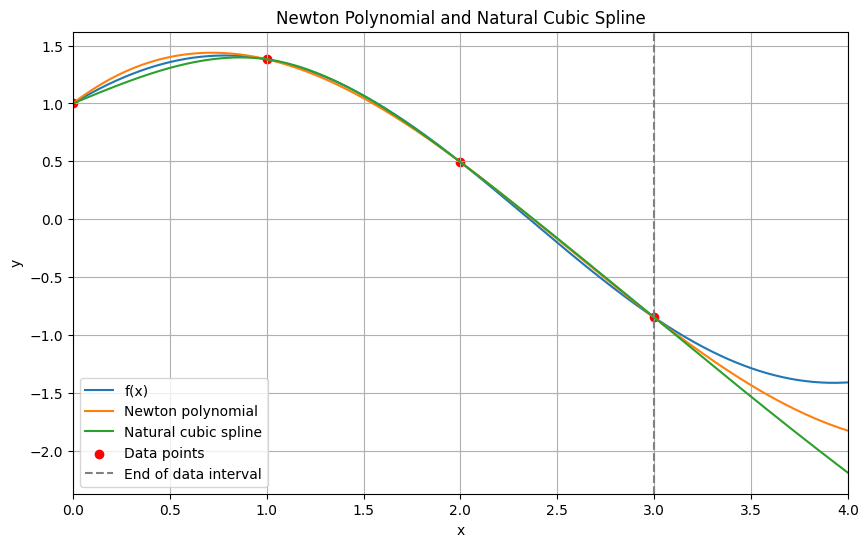

In [ ]:
# Now we can plot a graph to better visualize the differnce of the three functions

x_plot = np.linspace(0, 4, 500)

true_plot = f(x_plot)
newton_plot = newton_polynomial(x_plot)

# The spline function evaluates one value at a time
spline_plot = []

for x in x_plot:
    spline_plot.append(natural_cubic_spline(x))


plt.figure(figsize=(10, 6))

plt.plot(x_plot, true_plot, label="f(x)")
plt.plot(x_plot, newton_plot, label="Newton polynomial")
plt.plot(x_plot, spline_plot, label="Natural cubic spline")

plt.scatter(
    x_spline,
    y_spline,
    color="red",
    label="Data points"
)

plt.axvline(
    3,
    color="gray",
    linestyle="--",
    label="End of data interval"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Newton Polynomial and Natural Cubic Spline")
plt.xlim(0, 4)
plt.grid()
plt.legend()
plt.show()

From the graph shown above, we can observe that both the Newton polynomial and the natural cubic spline pass through all
four data points. Inside the data interval, the two approximations stay
close to the original function.

The spline has its smallest comparison error at

$$
x=1.5,
$$

while the Newton polynomial has smaller errors at

$$
x=0.5
\qquad\text{and}\qquad
x=2.5.
$$

The Newton method uses one cubic polynomial over the entire interval.
The spline uses three cubic pieces whose first and second derivatives
agree at the interior nodes, so the pieces join smoothly.

Extrapolation begins after

$$
x=3.
$$

The graph shows both approximations moving away from the original
function in this region. At

$$
x=3.5,
$$

the Newton polynomial has a smaller error than the natural cubic spline.

## Conclusion

Both methods pass through the four data points and produce smooth approximations.  
But, the natural cubic spline was much more accurate at the middle comparison point.  
The Newton polynomial had smaller errors at three of the four required evaluation points.  
Therefore, Newton performed better overall here, although both methods became less accurate during extrapolation.